# Model 3: Product-Centered Recommender

The rating-prediction models show that user-level personalization is limited by sparse user histories. This notebook builds a more product-centered recommender using the stronger item-level signals in the dataset.

It answers two practical questions:

- Which products are strongest within a category?
- Which products are most relevant to a given product?

The ranking uses average rating, review count, sales rank, category, and Amazon related-product links.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import os
import ast
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 12})

## Load Ratings and Metadata

Ratings are used to estimate product quality. Metadata provides categories, sales rank, brand, title, and related-product links.


In [2]:
project_root = Path.cwd()

env_data_dir = os.getenv('DATA_DIR')
local_cfg_path = project_root / 'paths.local.json'

if env_data_dir:
    data_dir = Path(env_data_dir).expanduser()
elif local_cfg_path.exists():
    data_dir = Path(json.loads(local_cfg_path.read_text())['data_dir']).expanduser()
else:
    candidate = project_root / '15_Veterinarian_Recommendation'
    if not candidate.exists():
        candidate = project_root.parent.parent / '15_Veterinarian_Recommendation'
    data_dir = candidate

ratings_path = data_dir / 'ratings_Pet_Supplies.csv'
meta_path = data_dir / 'meta_Pet_Supplies.json'

ratings_df = pd.read_csv(
    ratings_path,
    header=None,
    names=['user_id', 'asin', 'rating', 'timestamp']
)

meta_data = []
with open(meta_path, 'r') as f:
    for line in f:
        meta_data.append(ast.literal_eval(line))
meta_df = pd.DataFrame(meta_data)

print(f"Ratings shape: {ratings_df.shape}")
print(f"Metadata shape: {meta_df.shape}")

Ratings shape: (1235316, 4)
Metadata shape: (110707, 9)


## Build Product Table

Ratings are aggregated at product level and merged with metadata. The score uses a weighted rating so products with very few reviews are not ranked too highly just because they have a perfect average.


In [3]:
def flatten_leaf_categories(cat_val):
    if cat_val is None:
        return []
    if isinstance(cat_val, float) and np.isnan(cat_val):
        return []
    try:
        nested = ast.literal_eval(cat_val) if isinstance(cat_val, str) else cat_val
        if not isinstance(nested, list):
            return []
        leaves = [path[-1] for path in nested if isinstance(path, list) and path]
        return [c for c in leaves if c not in ['Pet Supplies', 'Pet Supplies: International Shipping Available']]
    except Exception:
        return []

def extract_pet_rank(rank_val):
    if pd.isna(rank_val):
        return np.nan
    try:
        d = ast.literal_eval(rank_val) if isinstance(rank_val, str) else rank_val
        return float(d.get('Pet Supplies', np.nan))
    except Exception:
        return np.nan

item_stats = (
    ratings_df
    .groupby('asin')
    .agg(
        avg_rating=('rating', 'mean'),
        review_count=('rating', 'count'),
        rating_std=('rating', 'std')
    )
    .reset_index()
)

meta_product = meta_df.copy()
meta_product['brand_clean'] = meta_product['brand'].replace('', np.nan).fillna('Unknown')
meta_product['leaf_categories'] = meta_product['categories'].apply(flatten_leaf_categories)
meta_product['primary_category'] = meta_product['leaf_categories'].apply(lambda x: x[0] if len(x) else 'Unknown')
meta_product['sales_rank_numeric'] = meta_product['salesRank'].apply(extract_pet_rank)

product_df = item_stats.merge(
    meta_product[['asin', 'title', 'brand_clean', 'price', 'primary_category', 'leaf_categories', 'sales_rank_numeric', 'related']],
    on='asin',
    how='left'
)

global_mean = ratings_df['rating'].mean()
confidence_prior = 20
product_df['weighted_rating'] = (
    (product_df['review_count'] * product_df['avg_rating'] + confidence_prior * global_mean)
    / (product_df['review_count'] + confidence_prior)
)

# Normalize item-level signals to 0-1 for ranking.
product_df['rating_score'] = (product_df['weighted_rating'] - 1) / 4
product_df['confidence_score'] = np.log1p(product_df['review_count']) / np.log1p(product_df['review_count'].max())

rank_clean = product_df['sales_rank_numeric'].dropna()
rank_min = np.log1p(rank_clean.min())
rank_max = np.log1p(rank_clean.max())
product_df['sales_rank_score'] = 1 - ((np.log1p(product_df['sales_rank_numeric']) - rank_min) / (rank_max - rank_min))
product_df['sales_rank_score'] = product_df['sales_rank_score'].fillna(product_df['sales_rank_score'].median())

product_df['quality_score'] = (
    0.55 * product_df['rating_score']
    + 0.30 * product_df['confidence_score']
    + 0.15 * product_df['sales_rank_score']
)

print(f"Product table shape: {product_df.shape}")
product_df[['asin', 'title', 'avg_rating', 'review_count', 'weighted_rating', 'quality_score', 'primary_category']].head()

Product table shape: (103288, 16)


,asin,title,avg_rating,review_count,weighted_rating,quality_score,primary_category
0,0615553605,Pet Qwerks Treat Cookbook with Cutters,3.333333,3,4.009317,0.496394,Toys
1,0615583474,It's A Cat's Life,5.000000,8,4.364796,0.543377,Unknown
2,0972585419,Feathered Phonics The Easy Way To Teach Your B...,3.130435,23,3.586379,0.508629,Unknown
3,0975412809,Notes From The Grooming Table by Melissa Verplank,4.641509,53,4.496086,0.691566,Grooming
4,0975412868,Theory of Five Book by Melissa Verplank,3.857143,7,4.044973,0.517576,Grooming


## Top Products by Category

This recommends strong products inside a chosen category. The ranking combines rating quality, review confidence, and sales-rank popularity.


In [4]:
def recommend_top_products_by_category(category, n=10, min_reviews=20):
    mask = product_df['leaf_categories'].apply(lambda cats: category in cats if isinstance(cats, list) else False)
    candidates = product_df[mask & (product_df['review_count'] >= min_reviews)].copy()
    return (
        candidates
        .sort_values('quality_score', ascending=False)
        [['asin', 'title', 'brand_clean', 'primary_category', 'avg_rating', 'review_count', 'weighted_rating', 'sales_rank_numeric', 'quality_score']]
        .head(n)
    )

example_category = 'Squeak Toys'
recommend_top_products_by_category(example_category, n=10, min_reviews=20)

,asin,title,brand_clean,primary_category,avg_rating,review_count,weighted_rating,sales_rank_numeric,quality_score
5739,B0002I0O60,Kyjen Hide-A-Squirrel Puzzle Toy for Dogs,Kyjen,Squeak Toys,4.342991,2347,4.341028,124.0,0.839404
18396,B000NVA06A,Kyjen PP01045 Squeakin' Animals Hide-A-Squirre...,Kyjen,Squeak Toys,4.544643,224,4.509075,757.0,0.756251
50885,B0042I5G2I,Kyjen PP02290 Tail Teaser Dog Toys Squeak Toy ...,Kyjen,Squeak Toys,4.575646,271,4.543692,2078.0,0.755699
25846,B00176CGK8,Kyjen PP01278 Squeakin' Eggs Plush Dog Toys Sq...,Kyjen,Squeak Toys,4.401929,311,4.384333,646.0,0.752792
25877,B00176CT5U,"KONG Air Dog Squeakair Birthday Balls Dog Toy,...",KONG,Squeak Toys,4.008889,450,4.013222,41.0,0.747984
34941,B001WAFT80,Kyjen Plush Puppies Squeaker Mat Long Body Dog...,Kyjen,Squeak Toys,4.095855,772,4.096230,613.0,0.746518
2797,B0002AR17S,"KONG Puppy KONG Toy, Large, Assorted Pink/Blue",KONG,Squeak Toys,4.281319,455,4.274135,1219.0,0.743683
62082,B005AP3B8S,KONG Cozie Medium Dog Toy,KONG,Squeak Toys,3.967828,373,3.975100,45.0,0.734898
5738,B0002I0O5Q,Kyjen PP01055 Hide-A-Bee Plush Dog Toys 4-Piec...,Kyjen,Squeak Toys,4.330961,281,4.316327,1239.0,0.731962
27682,B001A6Y1BM,"Replacement Squeakers, Small, Medium or Large,...",Unknown,Squeak Toys,4.411765,459,4.399195,24182.0,0.725221


## Related Product Recommender

This recommends products related to a chosen product. It starts from Amazon's related-product links and reranks candidates using relationship strength and product quality.


In [5]:
relation_weights = {
    'bought_together': 1.00,
    'also_bought': 0.80,
    'buy_after_viewing': 0.60,
    'also_viewed': 0.40,
}

product_lookup = product_df.set_index('asin')

def get_related_candidates(asin):
    if asin not in product_lookup.index:
        return pd.DataFrame()

    related = product_lookup.loc[asin, 'related']
    if not isinstance(related, dict):
        return pd.DataFrame()

    candidate_scores = defaultdict(float)
    candidate_sources = defaultdict(list)

    for relation, weight in relation_weights.items():
        related_items = related.get(relation, [])
        if not isinstance(related_items, list):
            continue
        for rank_position, candidate_asin in enumerate(related_items, start=1):
            # Small decay keeps earlier related items slightly stronger.
            score = weight / np.sqrt(rank_position)
            candidate_scores[candidate_asin] += score
            candidate_sources[candidate_asin].append(relation)

    if not candidate_scores:
        return pd.DataFrame()

    candidates = pd.DataFrame({
        'asin': list(candidate_scores.keys()),
        'relatedness_score': list(candidate_scores.values()),
        'relation_sources': [', '.join(sorted(set(candidate_sources[a]))) for a in candidate_scores.keys()]
    })

    candidates = candidates.merge(
        product_df[['asin', 'title', 'brand_clean', 'primary_category', 'avg_rating', 'review_count', 'weighted_rating', 'sales_rank_numeric', 'quality_score']],
        on='asin',
        how='inner'
    )

    if candidates.empty:
        return candidates

    candidates['relatedness_norm'] = candidates['relatedness_score'] / candidates['relatedness_score'].max()
    candidates['final_score'] = 0.60 * candidates['relatedness_norm'] + 0.40 * candidates['quality_score']

    return candidates.sort_values('final_score', ascending=False)

def recommend_related_products(asin, n=10, min_reviews=5):
    candidates = get_related_candidates(asin)
    if candidates.empty:
        return candidates
    candidates = candidates[candidates['review_count'] >= min_reviews]
    return candidates[['asin', 'title', 'brand_clean', 'primary_category', 'relation_sources', 'avg_rating', 'review_count', 'weighted_rating', 'quality_score', 'relatedness_score', 'final_score']].head(n)

# Example: most-reviewed product in the dataset.
example_asin = product_df.sort_values('review_count', ascending=False).iloc[0]['asin']
print('Example product:')
print(product_lookup.loc[example_asin, ['title', 'brand_clean', 'primary_category', 'avg_rating', 'review_count']])
print()
recommend_related_products(example_asin, n=10, min_reviews=5)

Example product:
title               FURminator deShedding Tool for Dogs
brand_clean                                  Furminator
primary_category                         Shedding Tools
avg_rating                                     4.634948
review_count                                       4109
Name: B0040QOYZ2, dtype: object



,asin,title,brand_clean,primary_category,relation_sources,avg_rating,review_count,weighted_rating,quality_score,relatedness_score,final_score
0,B00I2Y1CNU,FURminator 285307 deShedding Ultra Premium Sha...,Furminator,Shampoos,"also_bought, also_viewed, bought_together",3.714286,7,4.007936,0.564394,1.897014,0.825758
1,B0045IJRDO,"FURminator deShedding Waterless Spray,",Furminator,Grooming,"also_bought, also_viewed, bought_together",3.927711,83,3.963245,0.644470,1.376072,0.693021
61,B00CD0H1ZC,Deshedding Tool &amp; Pet Grooming Tool For Sm...,Unknown,Shedding Tools,also_viewed,4.823799,1311,4.813084,0.918044,0.400000,0.493732
2,B0045IPMGK,FURminator deShedding Ultra Premium Shampoo,Furminator,Shampoos,"also_bought, also_viewed",4.347150,193,4.324950,0.703502,0.561880,0.459116
46,B0040QS3PO,FURminator deShedding Tool for Cats,Furminator,Shedding Tools,"also_bought, also_viewed",4.659276,2210,4.654356,0.875340,0.235702,0.424685
4,B0062Z0S3G,FURminator Curry Comb (104013),Furminator,Shower & Bath Accessories,"also_bought, also_viewed",3.980392,51,4.017103,0.635250,0.477784,0.405217
10,B0002IEYIE,"Earthbath All Natural Shampoo, 16-Ounce",Earthbath,Shampoos Plus Conditioners,also_bought,4.518280,465,4.501473,0.797502,0.230940,0.392044
28,B0002AR19Q,"KONG ZoomGroom, Dog Grooming Toy",KONG,Brushes,"also_bought, also_viewed",4.506689,598,4.493874,0.786042,0.218630,0.383567
18,B00CKFL93K,#1 Best-Selling Pet Stain &amp; Odor Eliminato...,Unknown,Odor & Stain Removers,also_bought,4.588665,547,4.571806,0.808751,0.163299,0.375150
7,B007B6VTZG,"KONG ZoomGroom, Dog Grooming Brush, Small, Boy...",KONG,Brushes,"also_bought, also_viewed",4.409836,61,4.335979,0.665096,0.333333,0.371467


## Product Recommender Diagnostics

These plots show the main score components and help check whether one signal dominates the ranking.


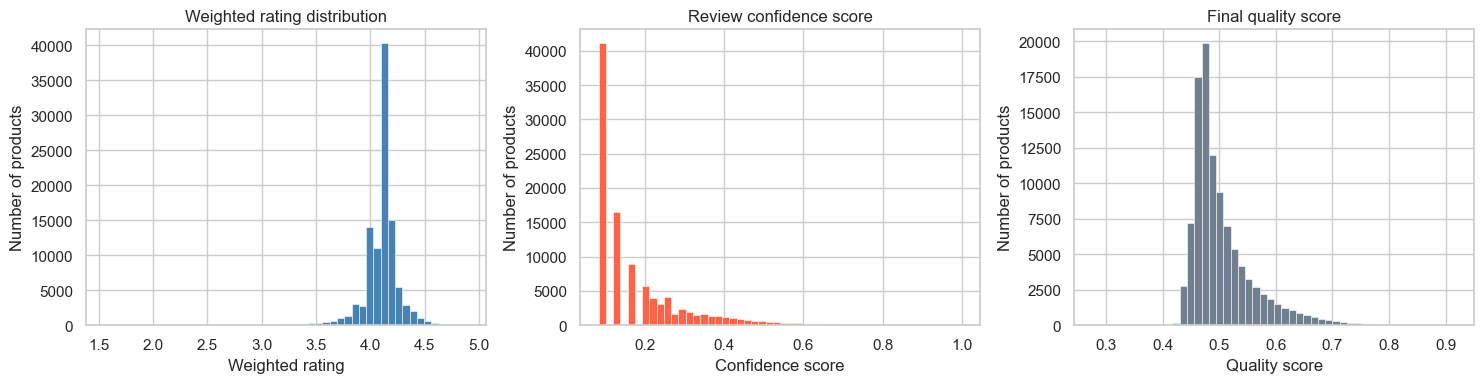

Top 15 products by product-centered quality score:


,asin,title,brand_clean,primary_category,avg_rating,review_count,weighted_rating,sales_rank_numeric,quality_score
92109,B00CD0H1ZC,Deshedding Tool &amp; Pet Grooming Tool For Sm...,Unknown,Shedding Tools,4.823799,1311,4.813084,6.0,0.918044
58585,B004X6UEH6,PetFusion Cat Scratcher Lounge - Deluxe,PetFusion,Beds,4.779252,2487,4.773919,305.0,0.890232
3674,B0002AT3M4,Midwest Life Stages Double-Door Folding Metal ...,Midwest Homes for Pets,Kennels,4.596466,2094,4.591871,23.0,0.889660
32014,B001LNSSH2,Zymox Otic Pet Ear Treatment with Hydrocortisone,Pet King Brands,Ear Care,4.808392,1978,4.801409,387.0,0.882900
4404,B0002DHV16,Cat Dancer 301 Cat Charmer Interactive Cat Toy,Cat Dancer Products,Toys,4.634637,1790,4.628848,40.0,0.882642
29179,B001DCAAP4,Duranimals DuraScoop Cat Litter Scoop (colors ...,Duranimals,Litter Scoops,4.832086,1203,4.820290,112.0,0.882438
10967,B0009X29WK,Precious Cat Ultra Premium Clumping Cat Litter...,Precious Cat,Litter & Refills,4.355256,1855,4.352648,1.0,0.882327
13519,B000F4AVPA,Chuckit! Small Ultra Ball,Canine Hardware,Balls,4.826127,1087,4.813202,77.0,0.882275
50105,B0040QS3PO,FURminator deShedding Tool for Cats,Furminator,Shedding Tools,4.659276,2210,4.654356,188.0,0.875340
56774,B004QBDO0M,Bayer K9 Advantage II Flea Control Treatment f...,Bayer,Flea Drops,4.362311,1852,4.359623,3.0,0.874880


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(product_df['weighted_rating'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Weighted rating distribution')
axes[0].set_xlabel('Weighted rating')
axes[0].set_ylabel('Number of products')

axes[1].hist(product_df['confidence_score'], bins=50, color='tomato', edgecolor='white', linewidth=0.4)
axes[1].set_title('Review confidence score')
axes[1].set_xlabel('Confidence score')
axes[1].set_ylabel('Number of products')

axes[2].hist(product_df['quality_score'], bins=50, color='slategray', edgecolor='white', linewidth=0.4)
axes[2].set_title('Final quality score')
axes[2].set_xlabel('Quality score')
axes[2].set_ylabel('Number of products')

plt.tight_layout()
plt.show()

print('Top 15 products by product-centered quality score:')
product_df.sort_values('quality_score', ascending=False)[[
    'asin', 'title', 'brand_clean', 'primary_category', 'avg_rating', 'review_count',
    'weighted_rating', 'sales_rank_numeric', 'quality_score'
]].head(15)

## Takeaway

This model is useful when exact user-level prediction is weak. It relies on product quality, popularity, category, and related-product links, so it can still give meaningful recommendations even when a user has little or no rating history.
